## Importing Needed Data

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    r2_score, mean_squared_error,
    accuracy_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    precision_score, recall_score, f1_score
)
from sklearn.model_selection import cross_val_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats as scipy_stats

# Load shared artifacts from Notebook 1
mi = joblib.load('model_inputs.pkl')
X_train      = mi['X_train']
X_test       = mi['X_test']
y_train_reg  = mi['y_train_reg']
y_test_reg   = mi['y_test_reg']
y_train_clf  = mi['y_train_clf']
y_test_clf   = mi['y_test_clf']

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"Features: {list(X_train.columns)}")


X_train: (83032, 22)  |  X_test: (20759, 22)
Features: ['Seniority', 'Policies_in_force', 'Max_policies', 'Max_products', 'N_claims_history', 'R_Claims_history', 'Second_driver', 'N_doors', 'Is_active', 'Driver_age', 'Licence_years', 'Vehicle_age', 'Fuel_diesel', 'Risk_tier_High Performance', 'Risk_tier_Premium', 'Risk_tier_Standard', 'Area_1', 'Type_risk_2', 'Type_risk_3', 'Type_risk_4', 'Distribution_channel_1', 'Payment_1']


# Part V. Multiple Linear Regression

### Step 1: Imports and feature scaling

In [2]:
# Identify continuous features (everything that ISN'T a 0/1 dummy/binary)
# After one-hot encoding, dummies are int 0/1 — they don't need scaling
binary_cols = [c for c in X_train.columns if X_train[c].nunique() == 2 and X_train[c].max() == 1]
continuous_cols = [c for c in X_train.columns if c not in binary_cols]

print(f"Continuous features (will scale): {len(continuous_cols)}")
for c in continuous_cols:
    print(f"  - {c}")
print(f"\nBinary features (left alone): {len(binary_cols)}")

# Fit scaler on TRAINING data only, then apply to both train and test
# (Fitting on the test set would leak information about the test distribution)
scaler_mlr = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[continuous_cols] = scaler_mlr.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler_mlr.transform(X_test[continuous_cols])

# Quick sanity check: scaled training continuous features should have mean ≈ 0, std ≈ 1
print(f"\nPost-scaling check on a sample column:")
print(f"  Driver_age (train) mean: {X_train_scaled['Driver_age'].mean():.4f} (should be ~0)")
print(f"  Driver_age (train) std:  {X_train_scaled['Driver_age'].std():.4f}  (should be ~1)")

Continuous features (will scale): 10
  - Seniority
  - Policies_in_force
  - Max_policies
  - Max_products
  - N_claims_history
  - R_Claims_history
  - N_doors
  - Driver_age
  - Licence_years
  - Vehicle_age

Binary features (left alone): 12

Post-scaling check on a sample column:
  Driver_age (train) mean: 0.0000 (should be ~0)
  Driver_age (train) std:  1.0000  (should be ~1)


### Step 2: Fit linear regression on Log_premium

In [3]:
# Fit OLS linear regression on scaled training features
mlr_premium = LinearRegression()
mlr_premium.fit(X_train_scaled, y_train_reg)

# Predict on both train and test
y_pred_train_log = mlr_premium.predict(X_train_scaled)
y_pred_test_log = mlr_premium.predict(X_test_scaled)

# R² on log scale
r2_train = r2_score(y_train_reg, y_pred_train_log)
r2_test = r2_score(y_test_reg, y_pred_test_log)

# RMSE on log scale
rmse_train_log = np.sqrt(mean_squared_error(y_train_reg, y_pred_train_log))
rmse_test_log = np.sqrt(mean_squared_error(y_test_reg, y_pred_test_log))

# RMSE in euros (back-transform with expm1 to undo log1p)
y_test_euros = np.expm1(y_test_reg)
y_pred_test_euros = np.expm1(y_pred_test_log)
rmse_test_euros = np.sqrt(mean_squared_error(y_test_euros, y_pred_test_euros))

print("Linear Regression — Premium Prediction")
print("=" * 45)
print(f"R² (train):        {r2_train:.4f}")
print(f"R² (test):         {r2_test:.4f}")
print(f"RMSE (train, log): {rmse_train_log:.4f}")
print(f"RMSE (test, log):  {rmse_test_log:.4f}")
print(f"RMSE (test, €):    {rmse_test_euros:.2f}")
print(f"\nMean test premium: €{y_test_euros.mean():.2f}")
print(f"RMSE as % of mean: {rmse_test_euros / y_test_euros.mean() * 100:.1f}%")

Linear Regression — Premium Prediction
R² (train):        0.4915
R² (test):         0.4869
RMSE (train, log): 0.3067
RMSE (test, log):  0.3103
RMSE (test, €):    119.17

Mean test premium: €318.45
RMSE as % of mean: 37.4%


The train and test R-squared values are very similar-- which is good! We have very little overfitting.
RMSE of €119.17 compared to the mean €318.45 is a bit more concerning-- that's 37.4% of the mean. This means that we have some room for improvement when we attempt this process with Random Forest.

### Step 3: Cross-validation for reporting

In [4]:
# 5-fold CV on the training set, scoring on R²
# (Confirms test R² isn't a fluke from one particular train/test split)
cv_scores = cross_val_score(
    LinearRegression(),
    X_train_scaled,
    y_train_reg,
    cv=5,
    scoring='r2'
)

print("5-Fold Cross-Validation R² (training set)")
print("=" * 45)
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\n  Mean:  {cv_scores.mean():.4f}")
print(f"  Std:   {cv_scores.std():.4f}")
print(f"\n  Test R² for comparison: {r2_test:.4f}")

5-Fold Cross-Validation R² (training set)
  Fold 1: 0.4830
  Fold 2: 0.4919
  Fold 3: 0.4908
  Fold 4: 0.4812
  Fold 5: 0.5083

  Mean:  0.4910
  Std:   0.0096

  Test R² for comparison: 0.4869


Performance is consistent across folds, which is evident in our cross-validation above.

### Step 4: Top coefficients by magnitude

Top 15 Linear Regression Coefficients (Log_premium)
                   feature  coefficient
               Type_risk_4    -0.783532
Risk_tier_High Performance     0.574339
         Risk_tier_Premium     0.418419
               Type_risk_3     0.410292
               Type_risk_2     0.393677
        Risk_tier_Standard     0.331339
                 Payment_1     0.143082
             Second_driver     0.131490
               Vehicle_age    -0.101354
                 Is_active    -0.066534
         Policies_in_force    -0.038749
                    Area_1     0.035699
          N_claims_history     0.026836
          R_Claims_history     0.021767
    Distribution_channel_1     0.021332


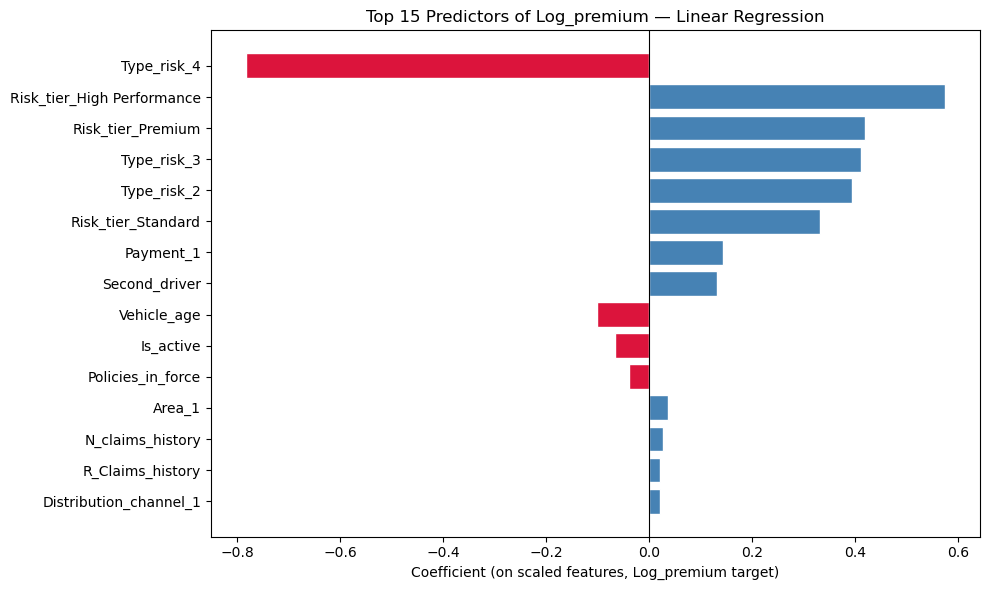

In [5]:
# Build a coefficient table sorted by absolute magnitude
# Because features are scaled, coefficients are directly comparable across features
coef_table = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'coefficient': mlr_premium.coef_,
    'abs_coef': np.abs(mlr_premium.coef_)
}).sort_values('abs_coef', ascending=False).reset_index(drop=True)

print("Top 15 Linear Regression Coefficients (Log_premium)")
print("=" * 55)
print(coef_table.head(15)[['feature', 'coefficient']].to_string(index=False))

# Visualize
top15 = coef_table.head(15).iloc[::-1]  # reverse for horizontal bar chart
colors_bar = ['steelblue' if c > 0 else 'crimson' for c in top15['coefficient']]

plt.figure(figsize=(10, 6))
plt.barh(top15['feature'], top15['coefficient'], color=colors_bar, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient (on scaled features, Log_premium target)')
plt.title('Top 15 Predictors of Log_premium — Linear Regression')
plt.tight_layout()
plt.show()

The strongest predictors seem to be the Type_risks, which validates our choice to follow the PCA-driven categories earlier. The Type_risk factors are also in the expected order of significance- type 4 (high performance) > type 3 (premium) > standard (type 2)

### Step 5: Linear regression assumption checks

Variance Inflation Factors (continuous features)
          feature      VIF
    Licence_years 4.552172
       Driver_age 4.498498
     Max_policies 3.415278
Policies_in_force 2.889253
 N_claims_history 1.861319
        Seniority 1.513344
 R_Claims_history 1.343976
     Max_products 1.155028
      Vehicle_age 1.066715
          N_doors 1.044996


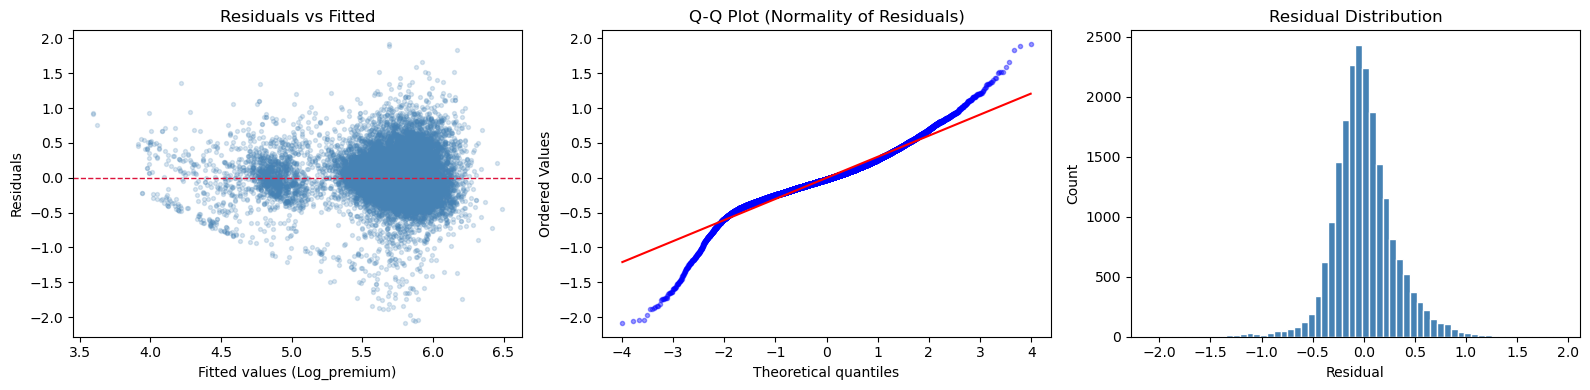


Residual summary stats:
  Mean:     -0.0017  (should be ~0)
  Std:      0.3103
  Skewness: -0.1051  (0 = symmetric)
  Kurtosis: 3.8745  (0 = normal)


In [6]:
# --- 5a: Variance Inflation Factor (multicollinearity) ---
# VIF < 5 is considered acceptable VIF. Higher than 5 indicates potentially problematic multicollinearity.
vif_data = pd.DataFrame({
    'feature': continuous_cols,
    'VIF': [
        variance_inflation_factor(X_train_scaled[continuous_cols].values, i)
        for i in range(len(continuous_cols))
    ]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print("Variance Inflation Factors (continuous features)")
print("=" * 50)
print(vif_data.to_string(index=False))

# --- 5b: Residual diagnostics ---
residuals = y_test_reg - y_pred_test_log

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Residuals vs Fitted: looking for random scatter around 0 (homoscedasticity + linearity)
axes[0].scatter(y_pred_test_log, residuals, alpha=0.2, s=8, color='steelblue')
axes[0].axhline(0, color='crimson', linestyle='--', linewidth=1)
axes[0].set_xlabel('Fitted values (Log_premium)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

# Q-Q plot: looking for points along the diagonal (normality of residuals)
scipy_stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot (Normality of Residuals)')
axes[1].get_lines()[0].set_markersize(3)
axes[1].get_lines()[0].set_alpha(0.4)

# Residual histogram: visual normality check
axes[2].hist(residuals, bins=60, color='steelblue', edgecolor='white')
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Count')
axes[2].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

print(f"\nResidual summary stats:")
print(f"  Mean:     {residuals.mean():.4f}  (should be ~0)")
print(f"  Std:      {residuals.std():.4f}")
print(f"  Skewness: {scipy_stats.skew(residuals):.4f}  (0 = symmetric)")
print(f"  Kurtosis: {scipy_stats.kurtosis(residuals):.4f}  (0 = normal)")

VIF is reassuringly below 5, so it is not a concern. Q-Q plot is also fairly reassuring-- we have the majority of midpoints hugging the line with derivations present on the extremes.
However, the Residuals v Fitted graph shows we have multiple clusters forming, showing a result that does not perfectly represent linear trends. Random Forest might be able to handle this better, which will be explored in Part VI.

### Step 6: Fit logistic regression on Claim_occurred and report validation results (Baseline - No Imbalance Correction)

Logistic Regression — Claim Occurrence
Accuracy: 0.8642
ROC-AUC:  0.9148

Confusion Matrix:
                 Predicted
                 No     Yes
  Actual No   16219    640
  Actual Yes   2179   1721

Classification Report:
              precision    recall  f1-score   support

    No claim       0.88      0.96      0.92     16859
       Claim       0.73      0.44      0.55      3900

    accuracy                           0.86     20759
   macro avg       0.81      0.70      0.73     20759
weighted avg       0.85      0.86      0.85     20759



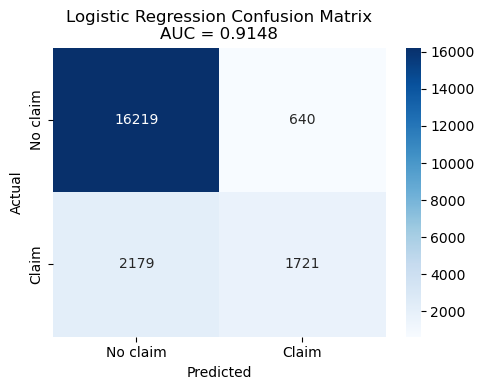

In [7]:
# Logistic regression for binary outcome (claim occurred yes/no)
# - max_iter=1000 to ensure convergence with this many features
# - class_weight='balanced' is worth considering since claim rate is ~19% (imbalanced),
#   but for this comparison we want vanilla logistic to compare against vanilla RF
mlr_claim = LogisticRegression(max_iter=1000, random_state=42)
mlr_claim.fit(X_train_scaled, y_train_clf)

# Predictions
y_pred_clf = mlr_claim.predict(X_test_scaled)
y_pred_proba = mlr_claim.predict_proba(X_test_scaled)[:, 1]  # P(claim=1)

# Metrics
accuracy = accuracy_score(y_test_clf, y_pred_clf)
auc = roc_auc_score(y_test_clf, y_pred_proba)
cm = confusion_matrix(y_test_clf, y_pred_clf)

print("Logistic Regression — Claim Occurrence")
print("=" * 45)
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC:  {auc:.4f}")
print(f"\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                 No     Yes")
print(f"  Actual No   {cm[0,0]:>5}  {cm[0,1]:>5}")
print(f"  Actual Yes  {cm[1,0]:>5}  {cm[1,1]:>5}")
print(f"\nClassification Report:")
print(classification_report(y_test_clf, y_pred_clf, target_names=['No claim', 'Claim']))

# Visualize confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No claim', 'Claim'],
            yticklabels=['No claim', 'Claim'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Logistic Regression Confusion Matrix\nAUC = {auc:.4f}')
plt.tight_layout()
plt.show()

AUC is 0.91, which is better than 86% accuracy. AUC is more reliable as a metric as well, as accuracy could be as high as 81% if the model predicted "no claim" for every claim. 44% is the recall on the positive class at default 0.5 threshold.

### Step 7: Top coefficients for logistic (log-odds)

Top 15 Logistic Regression Coefficients (Claim Occurrence)
                   feature  log_odds_coef  odds_ratio
          R_Claims_history       1.584282    4.875790
               Type_risk_4      -1.504595    0.222107
               Type_risk_2       0.653973    1.923167
               Type_risk_3       0.626079    1.870262
                 Is_active       0.477971    1.612799
          N_claims_history       0.259098    1.295761
         Policies_in_force       0.194579    1.214800
              Max_policies      -0.159607    0.852479
Risk_tier_High Performance      -0.151920    0.859057
        Risk_tier_Standard      -0.149326    0.861289
         Risk_tier_Premium      -0.135084    0.873643
                 Payment_1       0.086425    1.090270
                 Seniority      -0.082582    0.920736
               Vehicle_age      -0.038983    0.961767
                   N_doors       0.028867    1.029288


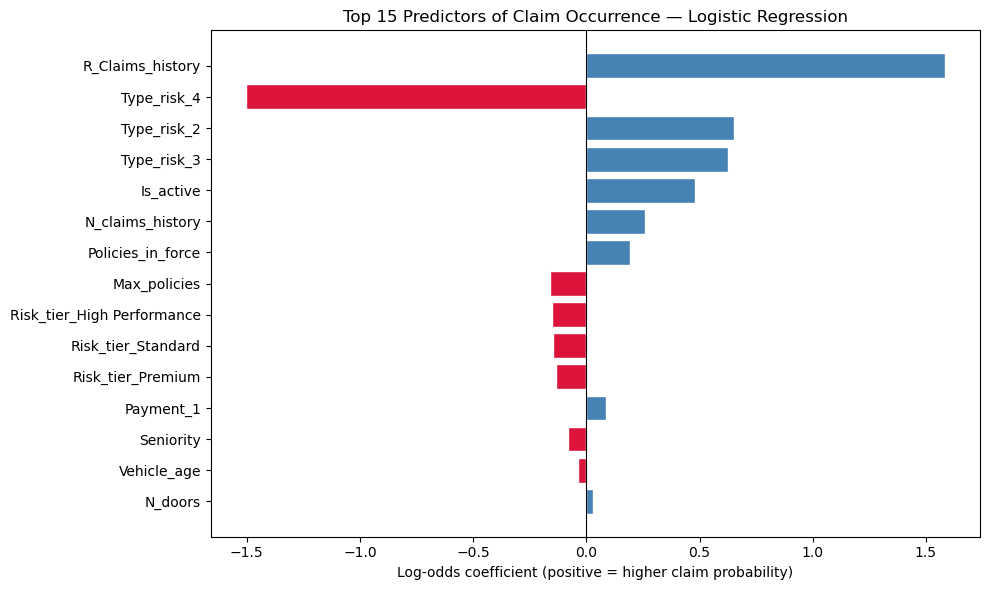

In [8]:
# Logistic coefficients are interpretable as log-odds shifts
# Exponentiate to get odds ratios (multiplier on probability of claim)
logit_coef_table = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'log_odds_coef': mlr_claim.coef_[0],
    'odds_ratio': np.exp(mlr_claim.coef_[0]),
    'abs_coef': np.abs(mlr_claim.coef_[0])
}).sort_values('abs_coef', ascending=False).reset_index(drop=True)

print("Top 15 Logistic Regression Coefficients (Claim Occurrence)")
print("=" * 60)
print(logit_coef_table.head(15)[['feature', 'log_odds_coef', 'odds_ratio']].to_string(index=False))

# Visualize
top15_logit = logit_coef_table.head(15).iloc[::-1]
colors_bar = ['steelblue' if c > 0 else 'crimson' for c in top15_logit['log_odds_coef']]

plt.figure(figsize=(10, 6))
plt.barh(top15_logit['feature'], top15_logit['log_odds_coef'], color=colors_bar, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Log-odds coefficient (positive = higher claim probability)')
plt.title('Top 15 Predictors of Claim Occurrence — Logistic Regression')
plt.tight_layout()
plt.show()

Having prior claims greatly increases the chance of a repeated claim-- which is consistent with logical assumptions.

### Step 8: Checking AUC without prior-claims features

In [9]:
# Sensitivity check: how much of the AUC comes from prior-claims features?
prior_claim_features = ['R_Claims_history', 'N_claims_history']
X_train_no_prior = X_train_scaled.drop(columns=prior_claim_features)
X_test_no_prior = X_test_scaled.drop(columns=prior_claim_features)

mlr_claim_no_prior = LogisticRegression(max_iter=1000, random_state=42)
mlr_claim_no_prior.fit(X_train_no_prior, y_train_clf)
y_pred_proba_no_prior = mlr_claim_no_prior.predict_proba(X_test_no_prior)[:, 1]
auc_no_prior = roc_auc_score(y_test_clf, y_pred_proba_no_prior)

print(f"AUC with prior-claims features:    {auc:.4f}")
print(f"AUC without prior-claims features: {auc_no_prior:.4f}")
print(f"AUC contribution from prior claims: {auc - auc_no_prior:.4f}")

AUC with prior-claims features:    0.9148
AUC without prior-claims features: 0.6462
AUC contribution from prior claims: 0.2686


AUC drops from 0.91 to 0.65 without prior-claims features, showing significant change. There is a clear impact of past claims on the likelihood of future claims-- again, noted before and consistent through testing.

## Part 5b - Logistic Regression: Imbalance Corrected

Having established a baseline, we now apply `class_weight='balanced'` to address the 4.4:1 class imbalance. This upweights minority-class (claim) misclassifications during training without altering the data itself.

In [10]:
# ── Helper — reuse for both notebooks ──
def get_clf_metrics(y_true, y_pred, y_proba, label):
    return {
        'model':     label,
        'auc':       roc_auc_score(y_true, y_proba),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'accuracy':  (y_true == y_pred).mean(),
        'cm':        confusion_matrix(y_true, y_pred)
    }

# ── Collect baseline metrics from the existing Step 6 variables ──
# (mlr_claim, y_pred_clf, y_pred_proba must already exist from Step 6)
lr_base_metrics = get_clf_metrics(y_test_clf, y_pred_clf, y_pred_proba,
                                   'Logistic — Baseline')

# ── Train balanced version ──
lr_balanced = LogisticRegression(max_iter=1000, random_state=42,
                                  class_weight='balanced')
lr_balanced.fit(X_train_scaled, y_train_clf)

lr_bal_pred  = lr_balanced.predict(X_test_scaled)
lr_bal_proba = lr_balanced.predict_proba(X_test_scaled)[:, 1]

lr_bal_metrics = get_clf_metrics(y_test_clf, lr_bal_pred, lr_bal_proba,
                                  'Logistic — Balanced')

# ── Print both ──
for m in [lr_base_metrics, lr_bal_metrics]:
    print(f"\n{'='*52}")
    print(f"  {m['model']}")
    print(f"{'='*52}")
    print(f"  ROC-AUC:   {m['auc']:.4f}   ← primary metric")
    print(f"  Recall:    {m['recall']:.4f}   ← % of actual claims caught")
    print(f"  Precision: {m['precision']:.4f}")
    print(f"  F1-Score:  {m['f1']:.4f}")
    print(f"  Accuracy:  {m['accuracy']:.4f}   ← de-emphasized (imbalanced target)")
    cm = m['cm']
    print(f"\n  Confusion Matrix:")
    print(f"               Pred No   Pred Yes")
    print(f"  Actual No    {cm[0,0]:>7,}    {cm[0,1]:>7,}")
    print(f"  Actual Yes   {cm[1,0]:>7,}    {cm[1,1]:>7,}  ← missed claims")


  Logistic — Baseline
  ROC-AUC:   0.9148   ← primary metric
  Recall:    0.4413   ← % of actual claims caught
  Precision: 0.7289
  F1-Score:  0.5498
  Accuracy:  0.8642   ← de-emphasized (imbalanced target)

  Confusion Matrix:
               Pred No   Pred Yes
  Actual No     16,219        640
  Actual Yes     2,179      1,721  ← missed claims

  Logistic — Balanced
  ROC-AUC:   0.9190   ← primary metric
  Recall:    0.7931   ← % of actual claims caught
  Precision: 0.5840
  F1-Score:  0.6727
  Accuracy:  0.8550   ← de-emphasized (imbalanced target)

  Confusion Matrix:
               Pred No   Pred Yes
  Actual No     14,656      2,203
  Actual Yes       807      3,093  ← missed claims


## Part 5c — Logistic Regression: Before vs. After Comparison

  LOGISTIC REGRESSION: Baseline vs. Balanced
              Model  ROC-AUC  Recall (Claims)  Precision  F1-Score  Accuracy
Logistic — Baseline   0.9148           0.4413     0.7289    0.5498    0.8642
Logistic — Balanced   0.9190           0.7931     0.5840    0.6727    0.8550

  Δ from applying class_weight='balanced':
    ΔAUC         : +0.0042  
    ΔRecall      : +0.3518  ← key gain
    ΔPrecision   : -0.1449  
    ΔF1          : +0.1229  
    ΔAccuracy    : -0.0092  ← expected


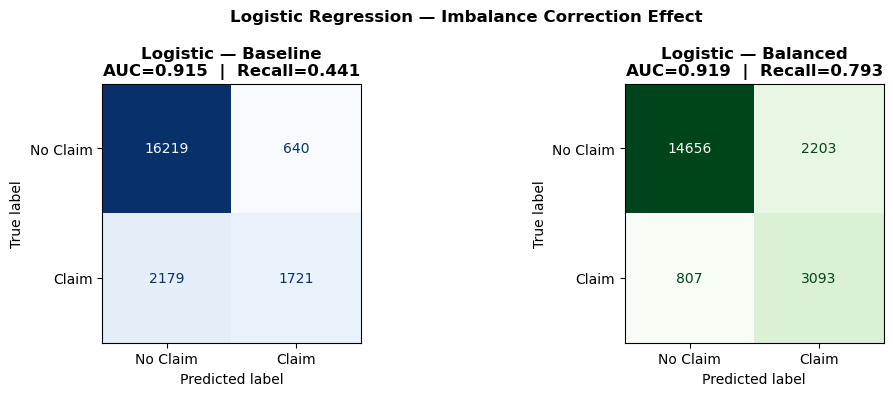

In [11]:
# ── Comparison table ──
lr_comparison = pd.DataFrame([{
    'Model':           m['model'],
    'ROC-AUC':         round(m['auc'], 4),
    'Recall (Claims)': round(m['recall'], 4),
    'Precision':       round(m['precision'], 4),
    'F1-Score':        round(m['f1'], 4),
    'Accuracy':        round(m['accuracy'], 4),
} for m in [lr_base_metrics, lr_bal_metrics]])

print("=" * 68)
print("  LOGISTIC REGRESSION: Baseline vs. Balanced")
print("=" * 68)
print(lr_comparison.to_string(index=False))

# ── Delta ──
print("\n  Δ from applying class_weight='balanced':")
for metric, col in [('AUC', 'ROC-AUC'), ('Recall', 'Recall (Claims)'),
                     ('Precision', 'Precision'), ('F1', 'F1-Score'), ('Accuracy', 'Accuracy')]:
    delta = lr_comparison.iloc[1][col] - lr_comparison.iloc[0][col]
    flag = '← key gain' if col == 'Recall (Claims)' and delta > 0 else \
           '← expected' if col == 'Accuracy' and delta < 0 else ''
    print(f"    Δ{metric:12s}: {delta:+.4f}  {flag}")

# ── Side-by-side confusion matrices ──
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
cmaps = ['Blues', 'Greens']
for ax, m, cmap in zip(axes, [lr_base_metrics, lr_bal_metrics], cmaps):
    disp = ConfusionMatrixDisplay(m['cm'], display_labels=['No Claim', 'Claim'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f"{m['model']}\nAUC={m['auc']:.3f}  |  Recall={m['recall']:.3f}",
                 fontweight='bold')
plt.suptitle('Logistic Regression — Imbalance Correction Effect',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Balancing seems to help MLR dramatically-- as we will see in the next step, it makes an even bigger difference than RF. Recall increases by 35pp for MLR, because logistic regression's decision boundary is more sensitive to class weights.

## Exporting data for future steps

In [12]:
# Save everything this notebook produced for downstream use
joblib.dump(mlr_premium,     'mlr_premium.pkl')      # regression model
joblib.dump(mlr_claim,       'mlr_claim.pkl')         # classification model
joblib.dump(scaler_mlr,      'scaler_mlr.pkl')        # fitted scaler
joblib.dump(continuous_cols, 'continuous_cols.pkl')   # which columns scaler applies to

mlr_metrics = {
    'model': 'Multiple Linear Regression (h2)',
    'regression': {
        'r2_train':       r2_train,
        'r2_test':        r2_test,
        'rmse_test_log':  rmse_test_log,
        'rmse_test_euros': rmse_test_euros,
        'cv_r2_mean':     cv_scores.mean(),
        'cv_r2_std':      cv_scores.std(),
    },
    'classification': {
        'accuracy':          accuracy,
        'roc_auc':           auc,
        'confusion_matrix':  cm.tolist(),
        'y_pred_proba':      y_pred_proba,   # needed for ROC curve in Notebook 5
    }
}
joblib.dump(mlr_metrics, 'mlr_metrics.pkl')
joblib.dump(lr_balanced,    'lr_claim_balanced.pkl')
joblib.dump(lr_comparison,  'lr_imbalance_comparison.pkl')

print("✓ mlr_premium.pkl")
print("✓ mlr_claim.pkl")
print("✓ scaler_mlr.pkl")
print("✓ continuous_cols.pkl")
print("✓ mlr_metrics.pkl")
print("✓ lr_claim_balanced.pkl")
print("✓ lr_imbalance_comparison.pkl")

✓ mlr_premium.pkl
✓ mlr_claim.pkl
✓ scaler_mlr.pkl
✓ continuous_cols.pkl
✓ mlr_metrics.pkl
✓ lr_claim_balanced.pkl
✓ lr_imbalance_comparison.pkl
